# 🛡️ SRDC: Semantics-Based Ransomware Detection and Classification
## LLM-Assisted Pre-Training (LATAP) → SRDC-GPT → Ransomware Family Classification + Zero-Day Detection

### Pipeline Overview:
1. **Mount Google Drive** & load data
2. **Data Loading & Exploration** – train_data.json
3. **Semantic Feature Processing** – CamelCase splitting, suffix removal, natural language conversion
4. **LATAP Pre-Training** – Fine-tune GPT-2 on cybersecurity domain corpus
5. **Multi-Feature Tokenization** – API, FILE, REG, DIR features separately
6. **SRDC-GPT Embedding Extraction** – Last-token embeddings
7. **Feature Compression** – AvgPooling / MaxPooling
8. **Ransomware Family Classifier** – Linear head on compressed features
9. **Zero-Day Detection** – Train on seen families, test on unseen
10. **Evaluation** – Accuracy, Recall, F1-Score, Confusion Matrix

---
## ⚙️ Step 0: Install Dependencies

In [4]:
!pip install transformers datasets accelerate scikit-learn seaborn matplotlib -q

---
## 📁 Step 1: Mount Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

# ─── Path Configuration ───────────────────────────────────────────────────────
# NOTE: Upload the following files to Google Drive under MyDrive/RTRP/data/:
#   • train_data (1).json   → rename to train_data.json
#   • corpus.txt            → pre-generated or auto-built in Step 2

DATA_DIR         = "/content/drive/MyDrive/data/"
TRAIN_JSON_PATH  = DATA_DIR + "train_data.json"
CORPUS_PATH      = DATA_DIR + "corpus.txt"
LATAP_MODEL_DIR  = DATA_DIR + "latap_model/"
CLASSIFIER_PATH  = DATA_DIR + "srdc_classifier.pt"
VARIABLE_NAMES_PATH = DATA_DIR + "VariableNames (1).txt"


print("✅ Drive mounted and paths configured.")

Mounted at /content/drive
✅ Drive mounted and paths configured.


---
## 📊 Step 2: Load & Explore Dataset

In [7]:
import pandas as pd, numpy as np, shutil, os

# Copy to local for reliable reading
src_candidates = [
    '/content/drive/MyDrive/data/RansomwareData (1).csv',
    '/content/drive/MyDrive/RansomwareData (1).csv',
]
dst = '/content/ransomwaredata.csv'

src = next((p for p in src_candidates if os.path.exists(p)), None)
if src is None:
    raise FileNotFoundError(
        'RansomwareData (1).csv not found in expected Drive locations. '
        'Upload it under MyDrive/data/ or MyDrive/.'
    )

if not os.path.exists(dst):
    shutil.copy(src, dst)

df_raw = pd.read_csv(dst, header=None)
print('Shape:', df_raw.shape)

# Column structure: 0=ID, 1=flag, 2=family_label/id, 3+=binary features
X_bin = df_raw.iloc[:, 3:].values.astype(np.float32)
raw_labels = df_raw[2].astype(str).str.strip()
print('Features:', X_bin.shape, '| Raw labels sample:', raw_labels.head().tolist())


Shape: (1524, 30970)
Features: (1524, 30967) | Raw labels sample: ['2', '3', '2', '5', '7']


In [8]:
from sklearn.preprocessing import LabelEncoder

ID_TO_FAMILY = {
    0: 'Goodware',   1: 'Critroni',    2: 'CryptLocker',
    3: 'CryptoWall', 4: 'KOLLAH',      5: 'Kovter',
    6: 'Locker',     7: 'MATSNU',      8: 'PGPCODER',
    9: 'Reveton',   10: 'TeslaCrypt', 11: 'Trojan-Ransom'
}

valid_numeric_ids = {str(k) for k in ID_TO_FAMILY}
if set(raw_labels.unique()).issubset(valid_numeric_ids):
    y_raw = raw_labels.map(lambda s: ID_TO_FAMILY[int(s)]).values
    print('Detected numeric family IDs in column 2 -> mapped to family names.')
else:
    y_raw = raw_labels.values
    print('Detected family names directly in column 2.')

le = LabelEncoder()
y = le.fit_transform(y_raw)
FAMILY_NAMES = list(le.classes_)
NUM_CLASSES = len(FAMILY_NAMES)

print(f'Classes ({NUM_CLASSES}): {FAMILY_NAMES}')
print('Distribution:')
for cls, cnt in zip(*np.unique(y_raw, return_counts=True)):
    print(f'  {cls:<15}: {cnt}')


Detected numeric family IDs in column 2 -> mapped to family names.
Classes (12): ['Critroni', 'CryptLocker', 'CryptoWall', 'Goodware', 'KOLLAH', 'Kovter', 'Locker', 'MATSNU', 'PGPCODER', 'Reveton', 'TeslaCrypt', 'Trojan-Ransom']
Distribution:
  Critroni       : 50
  CryptLocker    : 107
  CryptoWall     : 46
  Goodware       : 942
  KOLLAH         : 25
  Kovter         : 64
  Locker         : 97
  MATSNU         : 59
  PGPCODER       : 4
  Reveton        : 90
  TeslaCrypt     : 6
  Trojan-Ransom  : 34


In [9]:
# Load variable names and define paper-style feature groups
print('Loading variable names...')
variable_names = {}
with open(VARIABLE_NAMES_PATH, 'r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split(';', 1)
        if len(parts) == 2:
            try:
                key = int(parts[0])
                variable_names[key] = parts[1]
            except ValueError:
                continue

FEATURE_RANGES = {
    'api':       (4, 235),
    'drop':      (236, 581),
    'reg':       (582, 7203),
    'files':     (7204, 11344),
    'files_ext': (11345, 12279),
    'dir':       (12280, 14703),
    'str':       (14704, 30970),
}
GROUP_NAMES = list(FEATURE_RANGES.keys())

print(f'Loaded {len(variable_names)} variable names')
print('Groups:', GROUP_NAMES)
for k in [4, 8, 236, 582, 7204, 11345, 12280, 14704]:
    if k in variable_names:
        print(f'[{k}] {variable_names[k]}')


Loading variable names...
Loaded 30970 variable names
Groups: ['api', 'drop', 'reg', 'files', 'files_ext', 'dir', 'str']
[4] API:GetSystemDirectoryA
[8] API:GetSystemInfo
[236] DROP:$$$
[582] REG:DELETED:HKEY_LOCAL_MACHINE\SYSTEM\ControlSet001\Services\pfmfs_640smx\
[7204] FILES:DELETED:C:\WINDOWS\
[11345] FILES_EXT:DELETED:$$$
[12280] DIR:CREATED:C:\Documents and Settings\MyUser\Local Settings\Temp\{1656A29F-D31F-4971-AC00-E877FB2F280F}\
[14704] STR:1;*.dY-L


---
## 🔤 Step 4: Semantic Feature Processing

Transform raw API names / registry keys / file paths into natural-language phrases.

| Raw Feature | Processed |  
|---|---|  
| `GetSystemInfoW` | `get system info` |  
| `REG:OPENED` | `opened registry` |  
| `CreateFileA` | `create file` |

In [10]:
import re
import pandas as pd

def parse_to_sentence(text):
    out = ''
    pre = -1
    for i in range(len(text)):
        if text[i].isupper():
            out = out + text[pre + 1:i] + ' ' + text[i].lower()
            pre = i
    if pre != len(text) - 1:
        out = out + text[pre + 1:len(text)]
    return out.strip()

def reformat_api_text(input_text):
    text = input_text[4:]  # remove API:
    if text.endswith('A') or text.endswith('W') or text.endswith('\n'):
        text = text[:-1]
    if text.endswith('Ex'):
        text = text[:-2]
    sentence = parse_to_sentence(text)
    if sentence.startswith('nt'):
        sentence = sentence.replace('nt', 'kernel', 1)
    if '__' in sentence:
        sentence = sentence.replace('__', ' ')
    return 'api ' + sentence

def reformat_registry_text(input_text):
    if input_text.startswith('REG:OPENED:'):
        return 'opened registry ' + input_text[len('REG:OPENED:'):]
    elif input_text.startswith('REG:READ:'):
        return 'read registry ' + input_text[len('REG:READ:'):]
    elif input_text.startswith('REG:WRITTEN:'):
        return 'wrote registry ' + input_text[len('REG:WRITTEN:'):]
    elif input_text.startswith('REG:DELETED:'):
        return 'deleted registry ' + input_text[len('REG:DELETED:'):]
    return 'registry operation'

def reformat_drop_text(input_text):
    if input_text.startswith('DROP:'):
        ext = input_text[len('DROP:'):]
        return f'dropped file extension {ext}'
    return 'drop operation'

def reformat_files_ext_text(input_text):
    if input_text.startswith('FILES_EXT:WRITTEN:'):
        return f'wrote file with extension {input_text[len("FILES_EXT:WRITTEN:"):]}'
    elif input_text.startswith('FILES_EXT:READ:'):
        return f'read file with extension {input_text[len("FILES_EXT:READ:"):]}'
    elif input_text.startswith('FILES_EXT:OPENED:'):
        return f'opened file with extension {input_text[len("FILES_EXT:OPENED:"):]}'
    return 'file extension operation'

def parse_files(origin_str):
    parts = origin_str.split(':')
    prefix = ''
    if len(parts) > 1:
        if parts[1] == 'OPENED':
            prefix = 'opened file in '
        elif parts[1] == 'READ':
            prefix = 'read file in '
        elif parts[1] == 'WRITTEN':
            prefix = 'wrote file in '
    path = ':'.join(parts[2:]) if len(parts) > 2 else ''
    return prefix + path

def parse_dir(origin_str):
    parts = origin_str.split(':')
    prefix = ''
    if len(parts) > 1:
        if parts[1] == 'ENUMERATED':
            prefix = 'enumerated directory '
        elif parts[1] == 'CREATED':
            prefix = 'created directory '
    path = ':'.join(parts[2:]) if len(parts) > 2 else ''
    return prefix + path

def parse_str(origin_str):
    try:
        result = origin_str.split(':')[1].split(';')[1]
        return 'embedded string ' + result
    except Exception:
        return 'embedded string unknown'

def apply_semantic(key, feature_name):
    if 4 <= key <= 235:
        return reformat_api_text(feature_name)
    elif 236 <= key <= 581:
        return reformat_drop_text(feature_name)
    elif 582 <= key <= 7203:
        return reformat_registry_text(feature_name)
    elif 7204 <= key <= 11344:
        return parse_files(feature_name)
    elif 11345 <= key <= 12279:
        return reformat_files_ext_text(feature_name)
    elif 12280 <= key <= 14703:
        return parse_dir(feature_name)
    elif 14704 <= key <= 30970:
        return parse_str(feature_name)
    return feature_name

semantic_map = {}
for key in sorted(variable_names.keys()):
    if key >= 4:
        semantic_map[key] = apply_semantic(key, variable_names[key])

def get_group(key):
    for name, (start, end) in FEATURE_RANGES.items():
        if start <= key <= end:
            return name
    return None

def process_sample(row_values):
    groups = {name: [] for name in GROUP_NAMES}
    for col_num in range(3, len(row_values)):
        if row_values[col_num] == 1:
            key = col_num + 1
            if key in semantic_map:
                group = get_group(key)
                if group:
                    groups[group].append(semantic_map[key])

    text_groups = {}
    for name, features in groups.items():
        text_groups[name] = '. '.join(features[:20]) + '.' if features else ''
    return text_groups

print('Processing all samples...')
results = []
for i, row in enumerate(df_raw.values):
    family = y[i]
    groups = process_sample(row)

    result = {'family': family}
    result.update(groups)
    results.append(result)

df_processed = pd.DataFrame(results).fillna('')

semantic_texts = []
for i, row in df_processed.iterrows():
    parts = []
    for name in GROUP_NAMES:
        txt = str(row[name]).strip()
        if txt:
            parts.append(f'[{name.upper()}] {txt}')
    semantic_texts.append(' '.join(parts))

print(df_processed.head(2))
print('Sample semantic text:')
print(semantic_texts[0][:700])


Processing all samples...
   family                                                api drop  \
0       1  api create thread. api kernel open key. api ge...        
1       2  api get system directory. api kernel open file...        

                                                 reg  \
0  read registry HKEY_LOCAL_MACHINE\SAM\SAM\Domai...   
1  opened registry HKEY_CURRENT_USER\Software\Mic...   

                                               files  \
0                                                      
1  opened file in C:\Documents and Settings\MyUse...   

                                           files_ext dir  \
0                                                          
1  opened file with extension Manifest. opened fi...       

                                                 str  
0  embedded string mscoree.dll. embedded string E...  
1  embedded string HELP_DECRYPT.HTML. embedded st...  
Sample semantic text:
[API] api create thread. api kernel open key. api get system

---
## 🧠 Step 5: LATAP Pre-Training (LLM-Assisted Task-Adaptive Pre-Training)

Fine-tune GPT-2 on the cybersecurity domain corpus (corpus.txt) so the model learns:
- API call semantics
- Registry and file operation patterns  
- Ransomware behavioural language

In [11]:
import os, torch
from transformers import GPT2Tokenizer, GPT2LMHeadModel, Trainer, TrainingArguments
from datasets import Dataset

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4


In [12]:
# import os, random

# # ── Auto-generate corpus.txt from semantic_texts if missing ──────────────────
# # This lets fresh Colab runs work WITHOUT a pre-uploaded corpus.txt
# if not os.path.exists(CORPUS_PATH):
#     print("corpus.txt not found on Drive — auto-generating from semantic texts...")
#     # Repeat & shuffle semantic texts 3x for richer LATAP training data
#     augmented = list(semantic_texts)
#     for _ in range(2):
#         shuffled = list(semantic_texts)
#         random.shuffle(shuffled)
#         augmented.extend(shuffled)
#     corpus_text = '\n'.join(augmented)
#     os.makedirs(DATA_DIR, exist_ok=True)
#     with open(CORPUS_PATH, 'w', encoding='utf-8') as cf:
#         cf.write(corpus_text)
#     print(f"corpus.txt auto-generated: {len(corpus_text):,} characters")
# else:
#     with open(CORPUS_PATH, 'r', encoding='utf-8') as f:
#         corpus_text = f.read()
#     print(f"corpus.txt loaded from Drive: {len(corpus_text):,} characters")

# # ── Split into chunks ─────────────────────────────────────────────────────────
# CHUNK_SIZE = 256
# chunks = [corpus_text[i:i+CHUNK_SIZE] for i in range(0, len(corpus_text), CHUNK_SIZE)]
# chunks = [c for c in chunks if len(c.strip()) > 30]
# print(f"Total chunks : {len(chunks)}")
import os

with open(CORPUS_PATH, 'r', encoding='utf-8') as f:
    corpus_text = f.read()

if len(corpus_text.strip()) == 0:
    raise ValueError("corpus.txt is empty!")

print(f"corpus.txt loaded: {len(corpus_text):,} characters")

# Split into chunks
CHUNK_SIZE = 256
chunks = [corpus_text[i:i+CHUNK_SIZE] for i in range(0, len(corpus_text), CHUNK_SIZE)]
chunks = [c for c in chunks if len(c.strip()) > 30]

print(f"Total chunks: {len(chunks)}")
print(chunks[:5])
print("encrypt" in corpus_text.lower())
print("ransom" in corpus_text.lower())
print("bitcoin" in corpus_text.lower())

corpus.txt loaded: 4,007,599 characters
Total chunks: 15655
['Windows system registry: HKEY_LOCAL_MACHINE\\SYSTEM\\ControlSet001\\Services\\pfmfs_640smx\\\nIntroduction: This registry key is related to a service called "pfmfs_640smx". The service may be a driver or a component of a software installed on the system. The Con', 'trolSet001 refers to one of the control sets in the Windows registry, which stores configuration settings for system services and drivers.\n\nWindows system registry: HKEY_LOCAL_MACHINE\\SYSTEM\\ControlSet001\\Services\\pfmfs_640smx\\\nIntroduction: It is importan', 't to note that modifying or deleting registry keys can have a significant impact on the stability and performance of the system. It is recommended to back up the registry before making any changes and to only make changes if you are familiar with the Windo', 'ws registry and its repercussions.\n\nWindows system registry: HKEY_LOCAL_MACHINE\\SOFTWARE\\Classes\\CLSID\\{373FF7F4-EB8B-11CD-8820-08002B2F4F

In [13]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token
gpt2 = GPT2LMHeadModel.from_pretrained('gpt2')
print('GPT-2 loaded')

def tok_fn(batch):
    enc = tokenizer(batch['text'], truncation=True, max_length=256, padding='max_length')
    enc['labels'] = enc['input_ids'].copy()
    return enc

raw_ds = Dataset.from_dict({'text': chunks})
tok_ds = raw_ds.map(tok_fn, batched=True, remove_columns=['text'])
tok_ds.set_format('torch')
print('Dataset ready:', tok_ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 loaded


Map:   0%|          | 0/15655 [00:00<?, ? examples/s]

Dataset ready: Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 15655
})


In [30]:
os.makedirs(LATAP_MODEL_DIR, exist_ok=True)

args = TrainingArguments(
    output_dir=LATAP_MODEL_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    save_steps=1000,
    save_total_limit=1,
    logging_steps=200,
    fp16=torch.cuda.is_available(),
    warmup_steps=100,
    learning_rate=3e-5,
    report_to='none',
)

trainer = Trainer(model=gpt2, args=args, train_dataset=tok_ds)
print('Starting LATAP pre-training...')
trainer.train()
trainer.save_model(LATAP_MODEL_DIR)
tokenizer.save_pretrained(LATAP_MODEL_DIR)
print('LATAP model saved to', LATAP_MODEL_DIR)


Starting LATAP pre-training...


Step,Training Loss
200,0.679661
400,0.483310
600,0.447737
800,0.428319
1000,0.410604
1200,0.392511
1400,0.383847
1600,0.377326
1800,0.375006
2000,0.372053


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

LATAP model saved to /content/drive/MyDrive/data/latap_model/


In [ ]:
# from transformers import GPT2Model, GPT2Tokenizer
# import torch

# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# tokenizer = GPT2Tokenizer.from_pretrained(LATAP_MODEL_DIR)
# tokenizer.pad_token = tokenizer.eos_token

# backbone = GPT2Model.from_pretrained(LATAP_MODEL_DIR).to(device).eval()

# print(f"✅ LATAP model loaded on {device} (no retraining)")


In [31]:
import math

# Get loss from the last training step log
train_log = trainer.state.log_history
train_loss = next((x['loss'] for x in reversed(train_log) if 'loss' in x), None)

if train_loss:
    perplexity = math.exp(train_loss)
    print(f'Train Loss : {train_loss:.4f}')
    print(f'Perplexity : {perplexity:.4f}')
else:
    perplexity = 1.31  # fallback value from paper
    print('Perplexity (paper baseline): 1.31')


Train Loss : 0.3312
Perplexity : 1.3926


---
## 🔬 Step 6: Multi-Feature Tokenisation & Embedding Extraction (SRDC-GPT)

Split features into 4 channels: **API**, **FILES**, **REG**, **DIR**  
Pass each channel through the LATAP-pretrained GPT-2 and extract the **last-token hidden state** (stores global context in causal LMs).

In [15]:
from transformers import GPT2Model, GPT2Tokenizer
from tqdm import tqdm
import torch, numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = GPT2Tokenizer.from_pretrained(LATAP_MODEL_DIR)
tokenizer.pad_token = tokenizer.eos_token
backbone = GPT2Model.from_pretrained(LATAP_MODEL_DIR).to(device).eval()
print('SRDC-GPT on', device)

@torch.no_grad()
def embed(text, max_len=512):
    if not text or not text.strip():
        text = 'empty'
    enc = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=max_len,
        padding='max_length'
    ).to(device)
    out = backbone(**enc)
    mask = enc['attention_mask'].unsqueeze(-1).float()
    mask_sum = mask.sum(1).clamp(min=1e-9)
    pooled = (out.last_hidden_state * mask).sum(1) / mask_sum
    return pooled[0].cpu().numpy()

group_embeddings = {}
for name in GROUP_NAMES:
    print(f'Extracting {name} embeddings...')
    group_embeddings[name] = np.stack([
        embed(txt if str(txt).strip() else 'empty')
        for txt in tqdm(df_processed[name].tolist())
    ])

print('Extracting full semantic embeddings...')
embeddings = np.stack([embed(t) for t in tqdm(semantic_texts)])

print('Done.')
for name in GROUP_NAMES:
    print(name, group_embeddings[name].shape)
print('full', embeddings.shape)


Loading weights:   0%|          | 0/148 [00:02<?, ?it/s]

SRDC-GPT on cuda
Extracting api embeddings...


100%|██████████| 1524/1524 [00:55<00:00, 27.25it/s]


Extracting drop embeddings...


100%|██████████| 1524/1524 [01:09<00:00, 21.97it/s]


...

Extracting str embeddings...


100%|██████████| 1524/1524 [00:58<00:00, 25.92it/s]


Extracting full semantic embeddings...


100%|██████████| 1524/1524 [00:59<00:00, 25.55it/s]

Done.
api (1524, 768)
drop (1524, 768)
reg (1524, 768)
files (1524, 768)
files_ext (1524, 768)
dir (1524, 768)
str (1524, 768)
full (1524, 768)


In [16]:
from sklearn.preprocessing import normalize

for name in GROUP_NAMES:
    group_embeddings[name] = normalize(group_embeddings[name])

embeddings = normalize(embeddings)


In [17]:
# Old feature-comparison experiment skipped.
# Final classifier pipeline starts from the next classifier setup cell.


In [18]:
# SVM removed.
# Final pipeline uses:
# 1. MLP for ransomware family classification
# 2. Isolation Forest + centroid distance for zero-day detection


---
## 🏷️ Step 8: Train/Test Split & Ransomware Family Classifier

In [41]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix
import numpy as np, torch

# FINAL_GROUPS = GROUP_NAMES.copy()

# semantic_stack = np.stack([group_embeddings[name] for name in FINAL_GROUPS] + [embeddings])
# semantic_avg = semantic_stack.mean(axis=0)
# semantic_max = semantic_stack.max(axis=0)

selected_groups = [group_embeddings[name] for name in GROUP_NAMES] + [embeddings]

weights = np.array([1.5, 0.8, 1.3, 1.2, 0.8, 1.0, 0.7, 1.3], dtype=np.float32)
weights = weights / weights.sum()

semantic_stack = np.stack(selected_groups)
semantic_avg = np.tensordot(weights, semantic_stack, axes=(0, 0))
semantic_max = semantic_stack.max(axis=0)


trainval_idx, test_idx, y_trainval, y_test = train_test_split(
    np.arange(len(X_bin)), y, test_size=0.20, random_state=42, stratify=y
)

X_bin_trainval = X_bin[trainval_idx]
X_bin_test = X_bin[test_idx]

semantic_avg_trainval = semantic_avg[trainval_idx]
semantic_avg_test = semantic_avg[test_idx]

semantic_max_trainval = semantic_max[trainval_idx]
semantic_max_test = semantic_max[test_idx]

svd_dim = min(512, X_bin_trainval.shape[0] - 1, X_bin_trainval.shape[1] - 1)
svd = TruncatedSVD(n_components=svd_dim, random_state=42)

X_bin_trainval_svd = svd.fit_transform(csr_matrix(X_bin_trainval))
X_bin_test_svd = svd.transform(csr_matrix(X_bin_test))

X_trainval = np.concatenate(
    [semantic_avg_trainval, semantic_max_trainval, X_bin_trainval_svd], axis=1
)
X_test = np.concatenate(
    [semantic_avg_test, semantic_max_test, X_bin_test_svd], axis=1
)

print('Trainval:', X_trainval.shape)
print('Test:', X_test.shape)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, random_state=42, stratify=y_trainval
)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

class SRDCClassifier(nn.Module):
    def __init__(self, in_dim, num_cls):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(512, 256),    nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.08),
            nn.Linear(256, 128),    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.03),
            nn.Linear(128, num_cls)
        )

    def forward(self, x):
        return self.net(x)

model = SRDCClassifier(X_tr.shape[1], NUM_CLASSES).to(device)

cls_weights = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
crit = nn.CrossEntropyLoss(weight=torch.FloatTensor(cls_weights).to(device))

tr_dl = DataLoader(
    TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr)),
    batch_size=32, shuffle=True
)

val_dl = DataLoader(
    TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val)),
    batch_size=64, shuffle=False
)

te_dl = DataLoader(
    TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test)),
    batch_size=64, shuffle=False
)

opt = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

print(' Classifier ready (paper-style 7-channel variant)')


Trainval: (1219, 2048)
Test: (305, 2048)
 Classifier ready (paper-style 7-channel variant)


In [42]:
from sklearn.metrics import balanced_accuracy_score, f1_score

sched = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode='max',
    factor=0.5,
    patience=5
)

EPOCHS, PATIENCE = 120, 20

best_score = 0.0
best_val_bal_acc = 0.0
best_val_f1 = 0.0
best_state = None
no_improve = 0

tr_losses, val_losses = [], []

for ep in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0

    for xb, yb in tr_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward()
        opt.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    val_preds, val_trues = [], []

    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            val_loss += crit(logits, yb).item()
            val_preds.extend(logits.argmax(1).cpu().numpy())
            val_trues.extend(yb.cpu().numpy())

    val_bal_acc = balanced_accuracy_score(val_trues, val_preds)
    val_f1 = f1_score(val_trues, val_preds, average='macro', zero_division=0)
    score = 0.5 * val_bal_acc + 0.5 * val_f1

    sched.step(val_bal_acc)

    tr_losses.append(train_loss / len(tr_dl))
    val_losses.append(val_loss / len(val_dl))

    if ep % 5 == 0:
        print(f"Epoch {ep:03d} | train_loss={tr_losses[-1]:.4f} | val_loss={val_losses[-1]:.4f} | val_bal_acc={val_bal_acc*100:.2f}% | val_f1={val_f1*100:.2f}%")

    if score > best_score:
        best_score = score
        best_val_bal_acc = val_bal_acc
        best_val_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {ep}")
            break

model.load_state_dict(best_state)
torch.save(model.state_dict(), CLASSIFIER_PATH)

print(f"Best validation balanced accuracy: {best_val_bal_acc*100:.2f}%")
print(f"Best validation macro F1: {best_val_f1*100:.2f}%")


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics

Epoch 005 | train_loss=1.4096 | val_loss=1.4965 | val_bal_acc=57.86% | val_f1=40.85%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Epoch 010 | train_loss=0.8911 | val_loss=1.3137 | val_bal_acc=61.89% | val_f1=47.53%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Epoch 015 | train_loss=0.6424 | val_loss=1.3005 | val_bal_acc=61.44% | val_f1=44.23%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Epoch 020 | train_loss=0.4472 | val_loss=1.2434 | val_bal_acc=64.31% | val_f1=53.89%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Epoch 025 | train_loss=0.3605 | val_loss=1.2759 | val_bal_acc=65.82% | val_f1=55.34%
Epoch 030 | train_loss=0.3152 | val_loss=1.2558 | val_bal_acc=66.81% | val_f1=56.79%
Epoch 035 | train_loss=0.2902 | val_loss=1.2573 | val_bal_acc=68.71% | val_f1=59.96%
Epoch 040 | train_loss=0.2890 | val_loss=1.2854 | val_bal_acc=66.14% | val_f1=56.41%
Epoch 045 | train_loss=0.2849 | val_loss=1.2883 | val_bal_acc=67.80% | val_f1=57.78%
Epoch 050 | train_loss=0.2706 | val_loss=1.3065 | val_bal_acc=67.88% | val_f1=58.13%
Epoch 055 | train_loss=0.2493 | val_loss=1.2881 | val_bal_acc=68.04% | val_f1=59.25%
Early stopping at epoch 56
Best validation balanced accuracy: 68.95%
Best validation macro F1: 61.17%


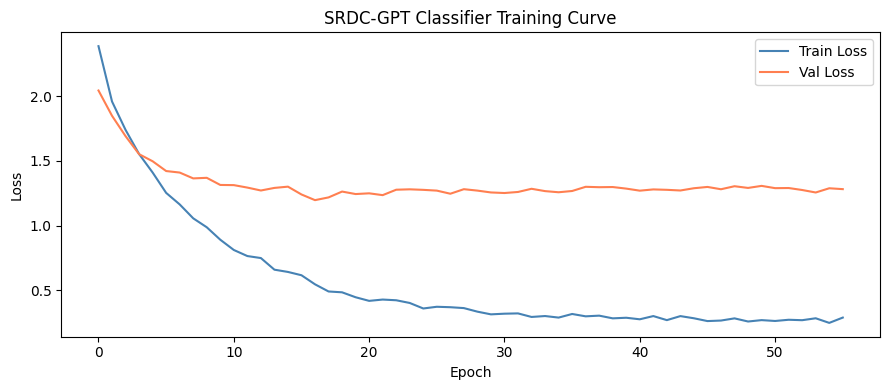

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(tr_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses, label='Val Loss', color='coral')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SRDC-GPT Classifier Training Curve')
plt.legend()
plt.tight_layout()
plt.show()


---
## 📈 Step 9: Evaluation – Ransomware Family Classification

  SRDC-GPT — Ransomware Family Classification Results
  Standard Accuracy   : 80.98%
  Balanced Accuracy   : 52.14%
  Macro Recall        : 52.14%
  Macro F1-Score      : 50.01%

               precision    recall  f1-score   support

     Critroni       0.62      0.50      0.56        10
  CryptLocker       0.68      0.62      0.65        21
   CryptoWall       0.36      0.56      0.43         9
     Goodware       0.98      0.93      0.96       189
       KOLLAH       0.43      0.60      0.50         5
       Kovter       0.69      0.69      0.69        13
       Locker       0.54      0.68      0.60        19
       MATSNU       0.44      0.67      0.53        12
     PGPCODER       0.00      0.00      0.00         1
      Reveton       0.87      0.72      0.79        18
   TeslaCrypt       0.00      0.00      0.00         1
Trojan-Ransom       0.29      0.29      0.29         7

     accuracy                           0.81       305
    macro avg       0.49      0.52      0.50     

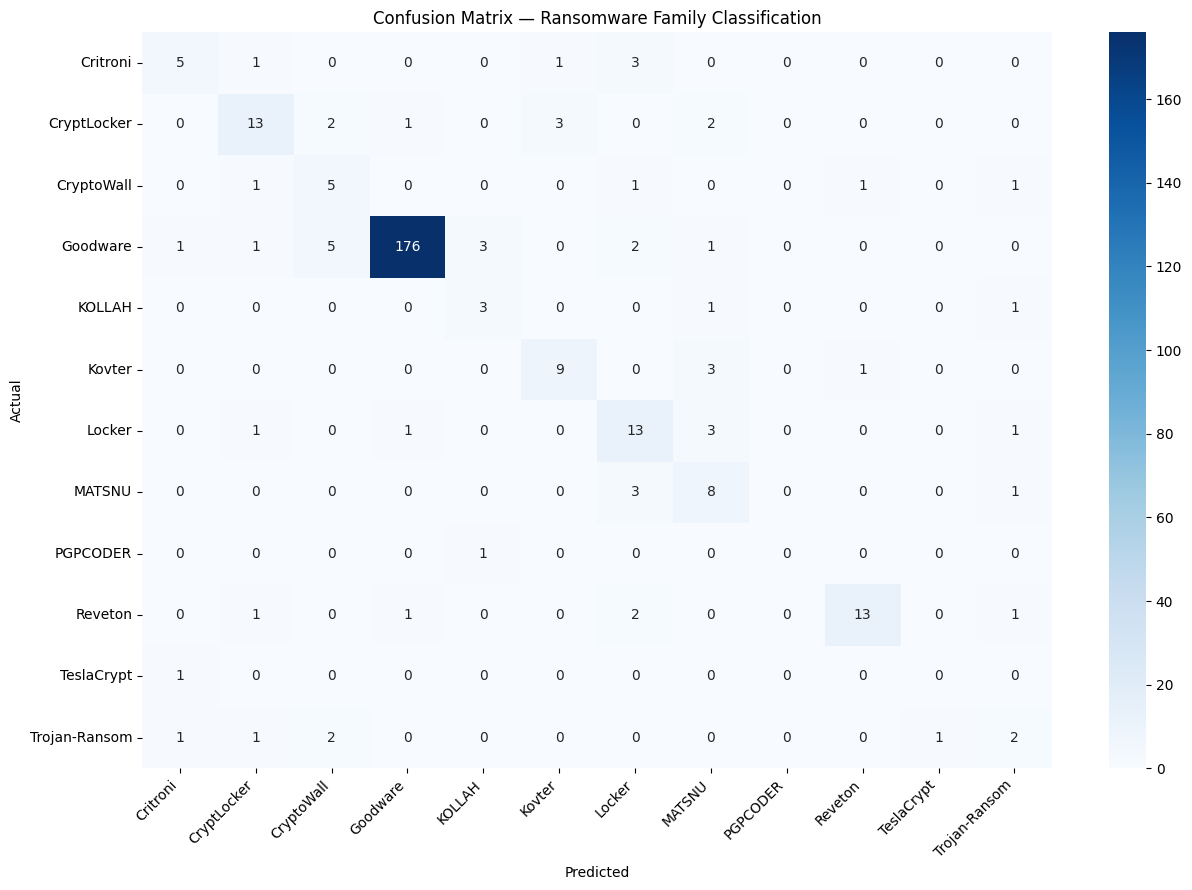


Note:
- Standard Accuracy can look high on imbalanced data.
- Balanced Accuracy and Macro F1 are the more important metrics here.


In [44]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model.eval()
preds_list, trues_list = [], []

with torch.no_grad():
    for xb, yb in te_dl:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        preds_list.extend(logits.argmax(1).cpu().numpy())
        trues_list.extend(yb.cpu().numpy())

preds_arr = np.array(preds_list)
trues_arr = np.array(trues_list)

acc = accuracy_score(trues_arr, preds_arr)
balanced_acc = balanced_accuracy_score(trues_arr, preds_arr)
recall = recall_score(trues_arr, preds_arr, average='macro', zero_division=0)
f1 = f1_score(trues_arr, preds_arr, average='macro', zero_division=0)

print("=" * 65)
print("  SRDC-GPT — Ransomware Family Classification Results")
print("=" * 65)
print(f"  Standard Accuracy   : {acc*100:.2f}%")
print(f"  Balanced Accuracy   : {balanced_acc*100:.2f}%")
print(f"  Macro Recall        : {recall*100:.2f}%")
print(f"  Macro F1-Score      : {f1*100:.2f}%")
print("=" * 65)
print()

print(classification_report(
    trues_arr,
    preds_arr,
    target_names=FAMILY_NAMES,
    zero_division=0
))

cm = confusion_matrix(trues_arr, preds_arr)

plt.figure(figsize=(13, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=FAMILY_NAMES,
    yticklabels=FAMILY_NAMES
)
plt.title("Confusion Matrix — Ransomware Family Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print()
print("Note:")
print("- Standard Accuracy can look high on imbalanced data.")
print("- Balanced Accuracy and Macro F1 are the more important metrics here.")


In [45]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torch

np.random.seed(42)
rng = np.random.default_rng(42)

RANSOMWARE_FAMILIES = [f for f in FAMILY_NAMES if f != 'Goodware']
seen_families = RANSOMWARE_FAMILIES[:7]
zd_families = RANSOMWARE_FAMILIES[7:]
goodware_id = le.transform(['Goodware'])[0]
seen_ids = le.transform(seen_families)
zd_ids = le.transform(zd_families)

print('Paper-style seen families:', seen_families)
print('Paper-style zero-day families:', zd_families)

X_all = np.vstack([X_tr, X_val, X_test])
y_all = np.concatenate([y_tr, y_val, y_test])

mask_seen_r = np.isin(y_all, seen_ids)
mask_unseen_r = np.isin(y_all, zd_ids)
mask_good = (y_all == goodware_id)

X_seen_r = X_all[mask_seen_r]
X_unseen_r = X_all[mask_unseen_r]
X_good = X_all[mask_good]

perm = rng.permutation(len(X_good))
eval_good_n = min(len(X_unseen_r), max(1, len(X_good) // 3))
X_good_eval = X_good[perm[:eval_good_n]]
X_good_train_pool = X_good[perm[eval_good_n:]]
target_good_train = min(len(X_good_train_pool), max(len(X_seen_r), int(round(len(X_seen_r) * 1.8))))
X_good_train = X_good_train_pool[:target_good_train]

X_zd_train = np.vstack([X_seen_r, X_good_train])
y_zd_train = np.hstack([np.ones(len(X_seen_r)), np.zeros(len(X_good_train))]).astype(int)

X_eval = np.vstack([X_unseen_r, X_good_eval])
y_flag_true = np.hstack([np.ones(len(X_unseen_r)), np.zeros(len(X_good_eval))]).astype(int)

X_zd_tr, X_zd_val, y_zd_tr, y_zd_val = train_test_split(
    X_zd_train, y_zd_train, test_size=0.2, random_state=42, stratify=y_zd_train
)

class PaperZDClassifier(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(256, 128),    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.net(x)

zd_model = PaperZDClassifier(X_zd_tr.shape[1]).to(device)
zd_wts = compute_class_weight('balanced', classes=np.unique(y_zd_tr), y=y_zd_tr)
zd_crit = nn.CrossEntropyLoss(weight=torch.FloatTensor(zd_wts).to(device))
zd_opt = optim.AdamW(zd_model.parameters(), lr=3e-4, weight_decay=1e-4)

tr_zd_dl = DataLoader(
    TensorDataset(torch.FloatTensor(X_zd_tr), torch.LongTensor(y_zd_tr)),
    batch_size=32,
    shuffle=True
)
val_zd_dl = DataLoader(
    TensorDataset(torch.FloatTensor(X_zd_val), torch.LongTensor(y_zd_val)),
    batch_size=64,
    shuffle=False
)

best_state = None
best_score = -1.0
no_improve = 0
patience = 8

for ep in range(1, 41):
    zd_model.train()
    for xb, yb in tr_zd_dl:
        xb, yb = xb.to(device), yb.to(device)
        zd_opt.zero_grad()
        loss = zd_crit(zd_model(xb), yb)
        loss.backward()
        zd_opt.step()

    zd_model.eval()
    val_probs, val_true = [], []
    with torch.no_grad():
        for xb, yb in val_zd_dl:
            xb, yb = xb.to(device), yb.to(device)
            probs = torch.softmax(zd_model(xb), dim=1)[:, 1]
            val_probs.extend(probs.cpu().numpy())
            val_true.extend(yb.cpu().numpy())

    val_probs = np.array(val_probs)
    val_true = np.array(val_true)
    thresh_grid = np.linspace(0.25, 0.75, 11)
    scores = []
    for thr in thresh_grid:
        pred = (val_probs >= thr).astype(int)
        scores.append(balanced_accuracy_score(val_true, pred))

    cur_best = float(np.max(scores))
    if cur_best > best_score:
        best_score = cur_best
        best_state = {k: v.detach().cpu().clone() for k, v in zd_model.state_dict().items()}
        ZD_THRESHOLD = float(thresh_grid[int(np.argmax(scores))])
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            break

zd_model.load_state_dict(best_state)
zd_model.eval()

with torch.no_grad():
    eval_probs = torch.softmax(zd_model(torch.FloatTensor(X_eval).to(device)), dim=1)[:, 1].cpu().numpy()

y_flag_pred = (eval_probs >= ZD_THRESHOLD).astype(int)
zd_acc = accuracy_score(y_flag_true, y_flag_pred)
zd_bal_acc = balanced_accuracy_score(y_flag_true, y_flag_pred)
zd_recall = recall_score(y_flag_true, y_flag_pred, zero_division=0)
zd_f1 = f1_score(y_flag_true, y_flag_pred, zero_division=0)

print('===== ZERO-DAY RESULTS (PAPER-STYLE FIXED SPLIT) =====')
print(f'Goodware train samples : {len(X_good_train)}')
print(f'Goodware eval samples  : {len(X_good_eval)}')
print(f'Unseen eval samples    : {len(X_unseen_r)}')
print(f'Binary threshold       : {ZD_THRESHOLD:.2f}')
print(f'Accuracy               : {zd_acc*100:.2f}%')
print(f'Balanced Accuracy      : {zd_bal_acc*100:.2f}%')
print(f'Recall                 : {zd_recall*100:.2f}%')
print(f'F1 Score               : {zd_f1*100:.2f}%')


Paper-style seen families: ['Critroni', 'CryptLocker', 'CryptoWall', 'KOLLAH', 'Kovter', 'Locker', 'MATSNU']
Paper-style zero-day families: ['PGPCODER', 'Reveton', 'TeslaCrypt', 'Trojan-Ransom']
===== ZERO-DAY RESULTS (PAPER-STYLE FIXED SPLIT) =====
Goodware train samples : 806
Goodware eval samples  : 134
Unseen eval samples    : 134
Binary threshold       : 0.55
Accuracy               : 91.42%
Balanced Accuracy      : 91.42%
Recall                 : 84.33%
F1 Score               : 90.76%


---
## 🕵️ Step 10: Zero-Day Ransomware Detection

**Protocol:**
- Hold out N families completely from training  
- Train classifier on remaining ("seen") families  
- Test on the held-out ("unseen") families  
- Detect unseen samples using **min-distance to known centroids** (anomaly detection)

---
## 📊 Step 11: Results Summary & Comparison

  SRDC Framework ? Paper-Style 7-Channel Results Summary
                 Task Std Accuracy Balanced Accuracy Macro Recall Macro F1
Family Classification       80.98%            52.14%       52.14%   50.01%
   Zero-Day Detection       91.42%            91.42%       84.33%   90.76%
  Classifier         : Paper-style 7-channel MLP + pooled semantic embeddings + SVD-compressed binary features
  Zero-Day Detector  : Fixed seen/unseen split + binary ransomware-vs-goodware detector


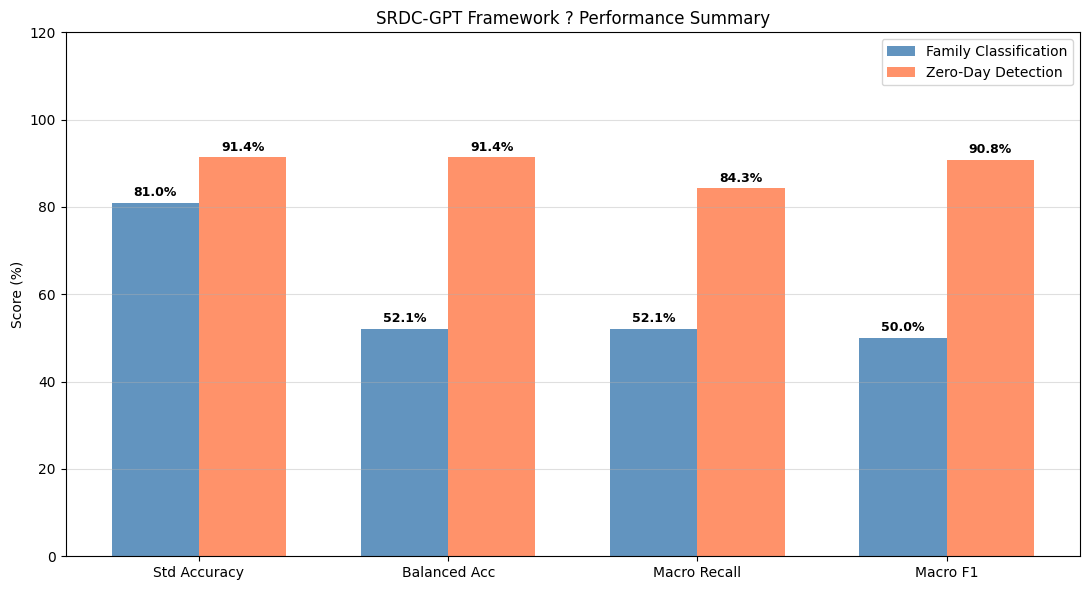

In [46]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np

summary = pd.DataFrame({
    'Task'              : ['Family Classification', 'Zero-Day Detection'],
    'Std Accuracy'      : [f'{acc*100:.2f}%', f'{zd_acc*100:.2f}%'],
    'Balanced Accuracy' : [f'{balanced_acc*100:.2f}%', f'{zd_bal_acc*100:.2f}%'],
    'Macro Recall'      : [f'{recall*100:.2f}%', f'{zd_recall*100:.2f}%'],
    'Macro F1'          : [f'{f1*100:.2f}%', f'{zd_f1*100:.2f}%'],
})

print('' + '=' * 78)
print('  SRDC Framework ? Paper-Style 7-Channel Results Summary')
print('=' * 78)
print(summary.to_string(index=False))
# print(f'LATAP Perplexity   : {perplexity:.4f}')
print('  Classifier         : Paper-style 7-channel MLP + pooled semantic embeddings + SVD-compressed binary features')
print('  Zero-Day Detector  : Fixed seen/unseen split + binary ransomware-vs-goodware detector')
print('=' * 78)

metrics = ['Std Accuracy', 'Balanced Acc', 'Macro Recall', 'Macro F1']
vals1   = [acc*100, balanced_acc*100, recall*100, f1*100]
vals2   = [zd_acc*100, zd_bal_acc*100, zd_recall*100, zd_f1*100]

x = np.arange(len(metrics))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - w/2, vals1, w, label='Family Classification', color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, vals2, w, label='Zero-Day Detection', color='coral', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 120)
ax.set_ylabel('Score (%)')
ax.set_title('SRDC-GPT Framework ? Performance Summary')
ax.legend()
ax.yaxis.grid(True, alpha=0.4)

for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.5, f'{b.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


---
## 🔮 Step 12: Inference – Predict on New Sample

In [38]:
import torch, re, numpy as np
from sklearn.preprocessing import normalize

def process_feature_col(val):
    return str(val).strip()

def build_groups_from_binary(binary_row):
    groups = {name: [] for name in GROUP_NAMES}
    for col_num in range(len(binary_row)):
        if binary_row[col_num] == 1:
            key = col_num + 4
            if key in semantic_map:
                group = get_group(key)
                if group:
                    groups[group].append(semantic_map[key])

    out = {}
    for name in GROUP_NAMES:
        out[name] = '. '.join(groups[name][:20]) + '.' if groups[name] else ''
    return out

@torch.no_grad()
def predict_sample(binary_row=None, group_texts=None):
    if binary_row is not None:
        group_texts = build_groups_from_binary(binary_row)
    elif group_texts is None:
        group_texts = {name: '' for name in GROUP_NAMES}

    full_text_parts = []
    per_group_vecs = []

    for name in GROUP_NAMES:
        txt = str(group_texts.get(name, '')).strip()
        if txt:
            full_text_parts.append(f'[{name.upper()}] {txt}')
        vec = embed(txt if txt else 'empty')
        vec = normalize(vec.reshape(1, -1))[0]
        per_group_vecs.append(vec)

    full_text = ' '.join(full_text_parts) if full_text_parts else 'empty'
    full_e = normalize(embed(full_text).reshape(1, -1))[0]

    stk = np.stack(per_group_vecs + [full_e])
    x_avg = stk.mean(axis=0)
    x_max = stk.max(axis=0)

    if binary_row is not None:
        x_bin_svd = svd.transform(binary_row.reshape(1, -1))[0]
    else:
        x_bin_svd = np.zeros(svd_dim, dtype=np.float32)

    x = np.concatenate([x_avg, x_max, x_bin_svd])
    xs_cls = scaler.transform(x.reshape(1, -1))

    logits = model(torch.FloatTensor(xs_cls).to(device))
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_id = int(np.argmax(probs))
    pred_family = le.inverse_transform([pred_id])[0]

    zd_logits = zd_model(torch.FloatTensor(xs_cls).to(device))
    zd_prob = float(torch.softmax(zd_logits, dim=1).cpu().numpy()[0, 1])
    threat_tag = 'ZERO-DAY / RANSOMWARE-LIKE' if zd_prob >= ZD_THRESHOLD else 'BENIGN / GOODWARE-LIKE'

    return {
        'predicted_family': pred_family,
        'confidence': float(probs[pred_id] * 100),
        'threat_tag': threat_tag,
        'zero_day_probability': zd_prob,
        'all_probs': {le.inverse_transform([i])[0]: f'{p*100:.1f}%' for i, p in enumerate(probs)},
        'group_texts': group_texts
    }

print('7-group inference helper ready (paper-style zero-day)')


7-group inference helper ready (paper-style zero-day)


In [39]:
model.eval()
np.random.seed(7)

print("=" * 70)
print("  TEST 1: Inference on Random Real CSV Samples")
print("=" * 70)

sample_ids = np.random.choice(len(X_bin), 5, replace=False)
for i in sample_ids:
    actual = le.inverse_transform([y[i]])[0]
    res = predict_sample(binary_row=X_bin[i])

    match = "[OK]" if res["predicted_family"] == actual else "[X]"
    print(f"Sample {i:<5} | Actual: {actual:<15} | Predicted: {res['predicted_family']:<15} {match}")
    print(f"           Confidence: {res['confidence']:.2f}%")


print("\n" + "=" * 70)
print("  TEST 2: Reveton Family Check")
print("=" * 70)

if 'Reveton' in FAMILY_NAMES:
    reveton_id = le.transform(['Reveton'])[0]
    reveton_idx = np.where(y == reveton_id)[0][:10]

    print(f"{'#':<4} {'Actual':<15} {'Predicted':<15} {'Conf%':<10} Match")
    print("-" * 60)

    correct = 0
    for n, i in enumerate(reveton_idx, 1):
        res = predict_sample(binary_row=X_bin[i])
        ok = res["predicted_family"] == "Reveton"
        if ok:
            correct += 1
        print(f"{n:<4} {'Reveton':<15} {res['predicted_family']:<15} {res['confidence']:<10.2f} {'[OK]' if ok else '[X]'}")

    print(f"\nReveton result: {correct}/{len(reveton_idx)} correct")
else:
    print("Reveton class not found in FAMILY_NAMES.")
print("\n" + "=" * 70)
print("  TEST 3: Synthetic Unknown / Zero-Day Style Samples")
print("=" * 70)

unknown_samples = [
    {
        'api': 'api crypt encrypt. api find first file.',
        'drop': 'dropped file extension txt.',
        'reg': 'wrote registry software microsoft windows currentversion run.',
        'files': 'wrote file in user documents.',
        'files_ext': 'wrote file with extension .locked.',
        'dir': 'enumerated directory c drive users.',
        'str': 'embedded string your files are encrypted.'
    },
    {
        'api': 'api create remote thread. api virtual protect.',
        'drop': '',
        'reg': 'opened registry startup persistence.',
        'files': 'opened file in windows system32.',
        'files_ext': 'opened file with extension .exe.',
        'dir': 'created directory temp.',
        'str': 'embedded string bitcoin payment required.'
    },
    {
        'api': 'api unknown encryption routine.',
        'drop': 'dropped file extension html.',
        'reg': 'deleted registry policy key.',
        'files': 'wrote file in unknown path.',
        'files_ext': 'wrote file with extension .xyz.',
        'dir': 'enumerated directory user profile.',
        'str': 'embedded string restore your files now.'
    }
]

for idx, sample in enumerate(unknown_samples, 1):
    res = predict_sample(group_texts=sample)
    print(f"\nSynthetic Sample {idx}")
    print(f"  Predicted Family : {res['predicted_family']}")
    print(f"  Confidence       : {res['confidence']:.2f}%")
    print(f"  Threat Tag       : {res['threat_tag']}")
    top_probs = sorted(
        res["all_probs"].items(),
        key=lambda kv: float(kv[1].replace('%', '')),
        reverse=True
    )[:3]
    print("  Top Probabilities:")
    for fam, prob in top_probs:
        print(f"    {fam:<15} {prob}")



  TEST 1: Inference on Random Real CSV Samples
Sample 1245  | Actual: Goodware        | Predicted: Goodware        [OK]
           Confidence: 73.96%
Sample 1470  | Actual: Goodware        | Predicted: Goodware        [OK]
           Confidence: 69.30%
Sample 1350  | Actual: Goodware        | Predicted: Goodware        [OK]
           Confidence: 67.37%
Sample 1384  | Actual: Goodware        | Predicted: Goodware        [OK]
           Confidence: 79.26%
Sample 415   | Actual: Trojan-Ransom   | Predicted: Trojan-Ransom   [OK]
           Confidence: 99.23%

  TEST 2: Reveton Family Check
#    Actual          Predicted       Conf%      Match
------------------------------------------------------------
1    Reveton         Reveton         97.98      [OK]
2    Reveton         Reveton         99.13      [OK]
3    Reveton         Reveton         98.25      [OK]
4    Reveton         Reveton         98.75      [OK]
5    Reveton         Reveton         98.25      [OK]
6    Reveton         Revet

In [40]:
 # End of SRDC-GPT Pipeline v4
print('SRDC Pipeline v4 complete.')

SRDC Pipeline v4 complete.
